In [3]:
import tensorflow as tf
from tensorflow.keras import backend as K
import cv2
from tensorflow.keras.models import load_model
import numpy as np
import matplotlib.pyplot as plt

def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    smooth = 1.0
    intersection = tf.reduce_sum(y_true * y_pred)
    return 1 - (2. * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )

c:\Users\chanu\anaconda3\envs\tensorNewGPU\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [4]:
model = load_model("C:\\Projects Datasets\\model_details\\unet_6\\model_2.h5",
                   custom_objects={"dice_coef": dice_coef},
                   compile=False)

In [38]:
img_path = "C:\Projects Datasets\pair\\25\mri.png"
image = cv2.imread(img_path)              # BGR format
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB

# Resize to model input size
image_resized = cv2.resize(image, (256, 256))

# Normalize to [0,1]
image_norm = image_resized / 255.0

# Add batch dimension
input_tensor = np.expand_dims(image_norm, axis=0) 

In [39]:
pred_mask = model.predict(input_tensor)

# Remove batch dimension
pred_mask = pred_mask[0]

# Threshold (convert probabilities to binary mask)
binary_mask = (pred_mask > 0.5).astype(np.uint8)

1/1 [==============================] - 0s 16ms/step


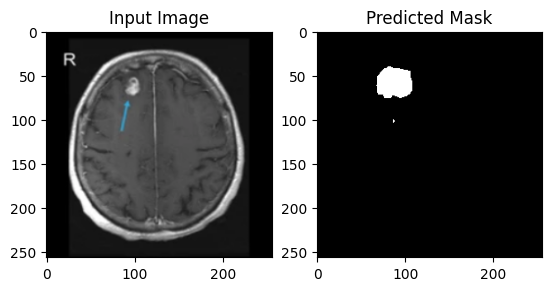

In [40]:
plt.subplot(1, 2, 1)
plt.imshow(image_resized)
plt.title("Input Image")

plt.subplot(1, 2, 2)
plt.imshow(binary_mask.squeeze(), cmap="gray")
plt.title("Predicted Mask")

plt.show()

In [8]:
#15
#22
#26
#25
#21
#16
#14
#11
#10
#9

#8
#7
#4
#3
#2

#24

In [9]:
import tensorflow as tf
print(tf.__version__)

2.10.1


In [10]:
print("GPU in use:", tf.test.gpu_device_name())

GPU in use: /device:GPU:0


In [11]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    details = tf.config.experimental.get_device_details(gpus[0])
    print(details)

{'device_name': 'NVIDIA GeForce RTX 4050 Laptop GPU', 'compute_capability': (8, 9)}


In [12]:
import os
from tensorflow.keras.models import load_model
import os
import tensorflow as tf

BASE_DIR =r"C:\\Users\\chanu\Downloads\DenseNet_trained"
dn_dir = os.path.join(BASE_DIR, "DenseNet_trained.keras")
model = tf.keras.models.load_model(dn_dir)

OSError: Unable to synchronously open file (file signature not found)

In [ ]:
import os, sys
import tensorflow as tf

BASE_DIR = r"C:\Users\chanu\Downloads\DenseNet_trained"
dn_path = os.path.join(BASE_DIR, "DenseNet_trained.keras")

print("TensorFlow:", tf.__version__)

try:
    import keras
    print("Keras:", keras.__version__)
except Exception as e:
    print("Standalone keras not installed/usable:", e)

print("Exists:", os.path.exists(dn_path))
print("Is file:", os.path.isfile(dn_path))
print("Is dir :", os.path.isdir(dn_path))
print("Folder listing:")
for p in os.listdir(BASE_DIR):
    print("  -", p)

TensorFlow: 2.10.1
Keras: 2.10.0
Exists: True
Is file: True
Is dir : False
Folder listing:
  - DenseNet_trained.keras
